Jasper Lim - 917038  \
John Buni - 9115726  \
Eche Oji - 9078881 

# PROG8431 – Solutions to  Highway Congestion​

Our problem concerns traffic congestion on provincial roads and highways in Southern Ontario. Congestion affects travel time, road efficiency, and the movement of people and goods. To investigate the problem, we identified publicly available transportation datasets from the Ontario Ministry of Transportation, Ontario Open Data, and 511 Ontario. These datasets provide historical traffic volumes, road information, traffic patterns, and related variables that can support analysis and machine learning. ​
​
**Our research question is: What factors contribute to highway congestion in Southern Ontario, and can historical traffic data be used to predict periods of high congestion, or identify alternative routes to aid decongestion? Future work could incorporate real-time traffic and incident data.​**

## Will it be one-time or ongoing?​

One-time analysis of the 2024 data; the same approach can be reused with future data.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib_venn import venn2

data = pd.read_excel('data/Provincial Highways Traffic Volumes 2024 AADT Only.xlsx')

#### Describe how data needs to undergo cleansing before it can be used during a Data Analysis experiment.

There are a few empty rows that have been used as separators between highways. We can use dataframe's .dropna() to remove these empty rows.

In [4]:
data = data.dropna(subset=["Distance (KM)", "2024 AADT"]).copy()

## From Challenge 3 - Understand the collected data and explain it in 1 minute

The data contains around 1800 entries which detail subsections of the Ontario provincial highway system, their length, and their AADT (average annual daily traffic.)

## From Challenge 4 - Encapsulate the code in classes, methods 

In [3]:
class HighwayTrafficAnalyzer:
    """Analyze Ontario provincial highway traffic volume data."""

    def __init__(self, data):
        """Store a copy of the highway dataset."""
        self.data = data.copy()

    def calculate_basic_statistics(self, column):
        """Calculate the mean, median, and mode for a numeric column."""

        return {
            "mean": round(self.data[column].mean(), 2),
            "median": round(self.data[column].median(), 2),
            "mode": self.data[column].mode().tolist()
        }

    def calculate_variability(self, column):
        """Calculate variance, standard deviation, and four quartiles."""

        series = self.data[column]

        return {
            "variance": series.var(),
            "standard_deviation": series.std(),
            "quartiles": series.quantile([0.25, 0.50, 0.75, 1.00])
        }

    def calculate_highway_averages(self):
        """Calculate average distance and AADT for each highway."""

        return self.data.groupby("Highway").agg(
            average_distance=("Distance (KM)", "mean"),
            average_aadt=("2024 AADT", "mean")
        )

In [4]:
analyzer = HighwayTrafficAnalyzer(data)

highway_averages = analyzer.calculate_highway_averages()

highway_averages.head()

,average_distance,average_aadt
Highway,,
2,0.940000,5800.000000
3,4.430889,10514.814815
4,5.769154,7903.846154
5,2.884200,10600.000000
6,7.620875,15993.571429


## From Challenge 5 - Calculate the mean, median, and mode in a way that makes sense 

In [13]:
# Challenge 5 - Mean, median, and mode

distance_stats = analyzer.calculate_basic_statistics("Distance (KM)")
aadt_stats = analyzer.calculate_basic_statistics("2024 AADT")

print("Distance (KM)")
print(f"  Mean:   {distance_stats['mean']:.2f}")
print(f"  Median: {distance_stats['median']:.2f}")
print(f"  Mode:   {distance_stats['mode']}")

print("\n2024 AADT")
print(f"  Mean:   {aadt_stats['mean']:,.2f}")
print(f"  Median: {aadt_stats['median']:,.2f}")
print(f"  Mode:   {aadt_stats['mode']}")

Distance (KM)
  Mean:   9.14
  Median: 5.11
  Mode:   [1.6]

2024 AADT
  Mean:   31,808.32
  Median: 7,350.00
  Mode:   [1050.0, 1650.0, 1900.0, 3600.0, 8450.0]


## From Challenge 6 - Calculate the variance standard deviation and four Quartiles in a way that makes sense


In [14]:
# Challenge 6 - Variability

distance_variability = analyzer.calculate_variability("Distance (KM)")
aadt_variability = analyzer.calculate_variability("2024 AADT")

print("Distance (KM)")
print(f"  Variance:           {distance_variability['variance']:,.2f}")
print(f"  Standard deviation: {distance_variability['standard_deviation']:,.2f}")
print("  Quartiles:")
print(distance_variability["quartiles"].to_string())

print("\n2024 AADT")
print(f"  Variance:           {aadt_variability['variance']:,.2f}")
print(f"  Standard deviation: {aadt_variability['standard_deviation']:,.2f}")
print("  Quartiles:")
print(aadt_variability["quartiles"].to_string())

Distance (KM)
  Variance:           155.50
  Standard deviation: 12.47
  Quartiles:
0.25      2.14175
0.50      5.10800
0.75     10.60000
1.00    104.68900

2024 AADT
  Variance:           4,450,535,012.10
  Standard deviation: 66,712.33
  Quartiles:
0.25      2012.5
0.50      7350.0
0.75     23500.0
1.00    511400.0


In [15]:
# Calculate variance and standard deviation separately for each highway.
# This provides an additional view of how distance and traffic volume
# vary between different highway groups.

distancestats = data.groupby("Highway")["Distance (KM)"].agg(
    variance="var",
    std="std"
)

aadtstats = data.groupby("Highway")["2024 AADT"].agg(
    variance="var",
    std="std"
)

# Display the variability results for each highway.
print("Distance variability by highway:")
print(distancestats)

print("\nAADT variability by highway:")
print(aadtstats)

Distance variability by highway:
          variance       std
Highway                     
2              NaN       NaN
3        12.883016  3.589292
4        11.210086  3.348147
5        14.560183  3.815781
6        64.761772  8.047470
...            ...       ...
560A           NaN       NaN
58A       6.294152  2.508815
607A           NaN       NaN
7A       31.184077  5.584270
QEW       2.279935  1.509946

[263 rows x 2 columns]

AADT variability by highway:
             variance           std
Highway                            
2                 NaN           NaN
3        7.924289e+07   8901.847538
4        9.143942e+06   3023.895221
5        4.702500e+07   6857.477670
6        1.822947e+08  13501.656656
...               ...           ...
560A              NaN           NaN
58A      4.512500e+05    671.751442
607A              NaN           NaN
7A       2.363187e+07   4861.262696
QEW      4.737791e+09  68831.609862

[263 rows x 2 columns]


## From Challenge 7 - Display the data with a scatter plot, a histogram, a box-whisker plot, and a Venn Diagram 

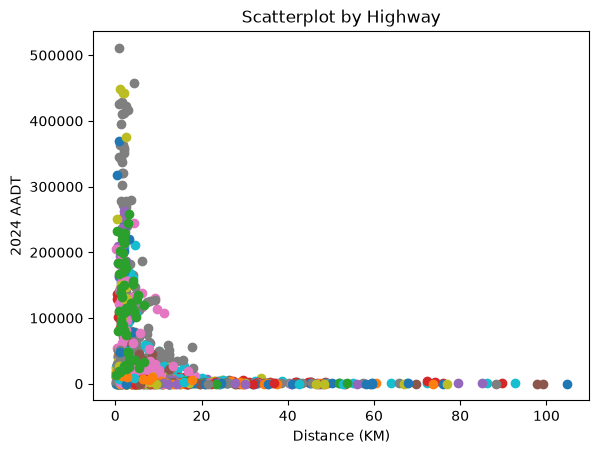

In [8]:
for group, group_data in data.groupby("Highway"):

    plt.scatter(
        group_data["Distance (KM)"],
        group_data["2024 AADT"],
        label=f"Highway {group}"
    )

plt.xlabel("Distance (KM)")
plt.ylabel("2024 AADT")
plt.title("Scatterplot by Highway")

# Legend omitted because there are many highway groups
plt.show()

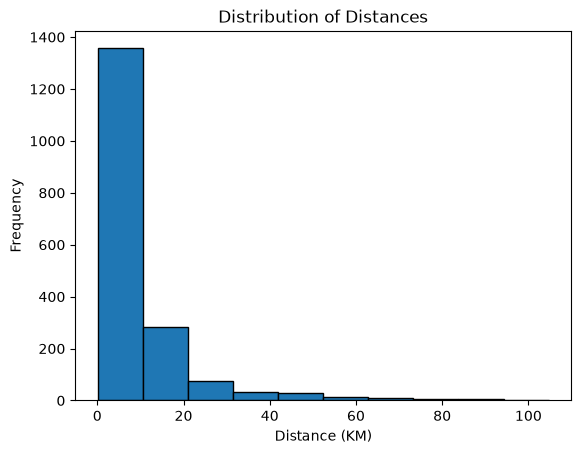

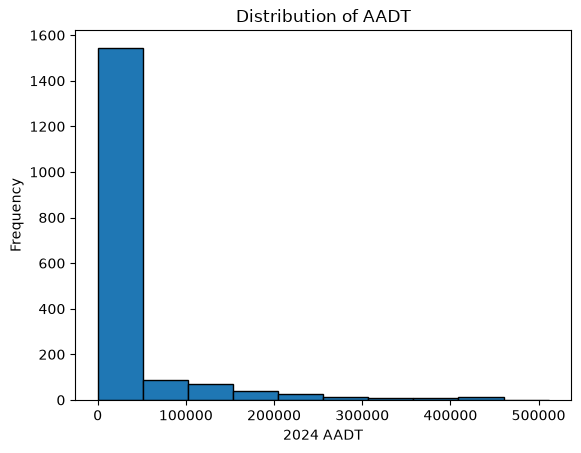

In [9]:
plt.hist(data["Distance (KM)"].dropna(), bins=10, edgecolor="black")
plt.xlabel("Distance (KM)")
plt.ylabel("Frequency")
plt.title("Distribution of Distances")
plt.show()

plt.hist(data["2024 AADT"].dropna(), bins=10, edgecolor="black")
plt.xlabel("2024 AADT") 
plt.ylabel("Frequency")
plt.title("Distribution of AADT")
plt.show()

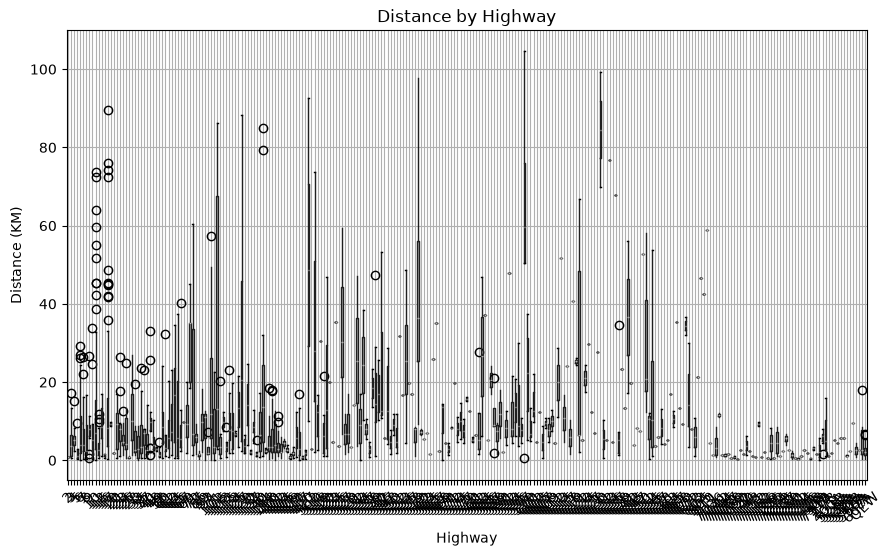

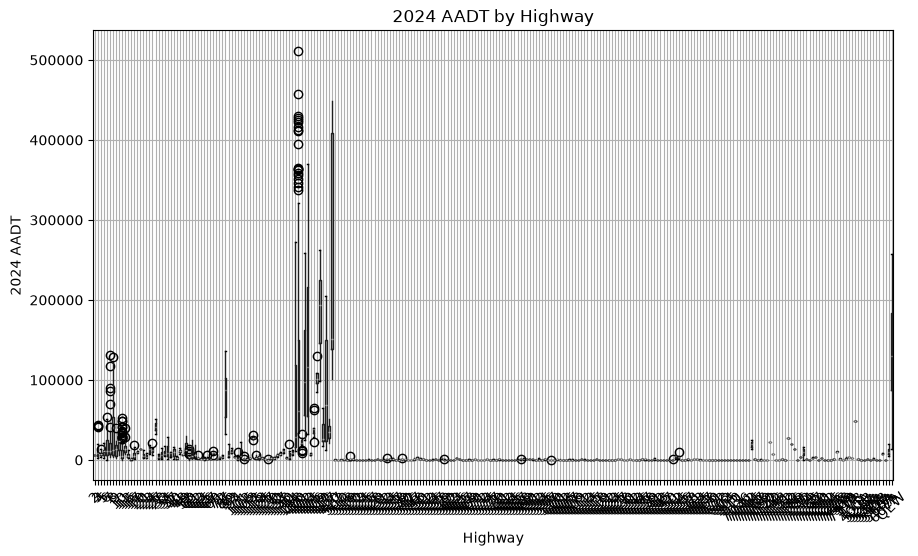

In [10]:
# Boxplot for Distance
data.boxplot(column="Distance (KM)", by="Highway", figsize=(10, 6))
plt.title("Distance by Highway")
plt.suptitle("")
plt.xlabel("Highway")
plt.ylabel("Distance (KM)")
plt.xticks(rotation=45)
plt.show()

# Boxplot for AADT
data.boxplot(column="2024 AADT", by="Highway", figsize=(10, 6))
plt.title("2024 AADT by Highway")
plt.suptitle("")
plt.xlabel("Highway")
plt.ylabel("2024 AADT")
plt.xticks(rotation=45)
plt.show()

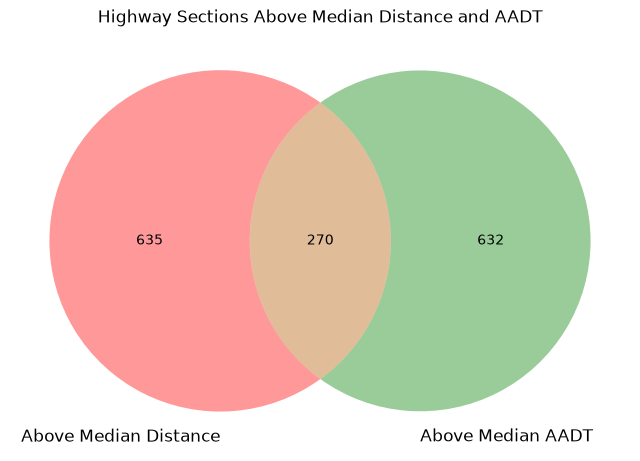

In [11]:
"""
Venn diagram comparing highway sections above the
median for distance and 2024 AADT. The overlap shows
sections above both medians.
"""
distance_median = data["Distance (KM)"].median()
aadt_median = data["2024 AADT"].median()

long_sections = set(data.index[data["Distance (KM)"] > distance_median])
high_traffic_sections = set(data.index[data["2024 AADT"] > aadt_median])

plt.figure(figsize=(8, 6))

venn2(
    [long_sections, high_traffic_sections],
    set_labels=("Above Median Distance", "Above Median AADT")
)

plt.title("Highway Sections Above Median Distance and AADT")
plt.show()

## From Challenge 7 - Present a numerical summary of the data

In [12]:
print(data.describe())

       Distance (KM)      2024 AADT
count    1810.000000    1810.000000
mean        9.143143   31808.320442
std        12.469999   66712.330285
min         0.100000      10.000000
25%         2.141750    2012.500000
50%         5.108000    7350.000000
75%        10.600000   23500.000000
max       104.689000  511400.000000
